In [5]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


In [6]:
# Mengecek direktori saat ini
current_dir = os.getcwd()
print("Direktori awal:", current_dir)

# Jika masih di dalam folder 'notebooks', naik satu tingkat ke folder root proyek
if current_dir.endswith("notebooks"):
    os.chdir("..")
    print("Direktori setelah disesuaikan:", os.getcwd())


Direktori awal: d:\pokemon-tcg-classification\notebooks
Direktori setelah disesuaikan: d:\pokemon-tcg-classification


In [7]:
# ==========================================
# 1. KONFIGURASI PARAMETER & DIREKTORI
# ==========================================
TRAIN_DIR = os.path.join("data", "processed", "train")
VAL_DIR = os.path.join("data", "processed", "val")

# Berdasarkan batasan: Resize 300x420 (width, height)
# Dalam Keras, format target_size adalah (height, width)
IMG_HEIGHT = 420
IMG_WIDTH = 300
BATCH_SIZE = 32
NUM_CLASSES = 10


In [8]:
# ==========================================
# 2. PRA-PEMROSESAN & AUGMENTASI DATA
# ==========================================
print("Menyiapkan Data Generator...")

# Augmentasi untuk data latih (Semi-clean + Augmentasi)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalisasi Piksel
    rotation_range=20,           # Rotasi
    brightness_range=[0.8, 1.2], # Brightness
    zoom_range=0.2,              # Zoom
    horizontal_flip=True         # Horizontal Flip
)

# Untuk data validasi, HANYA lakukan normalisasi piksel
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.


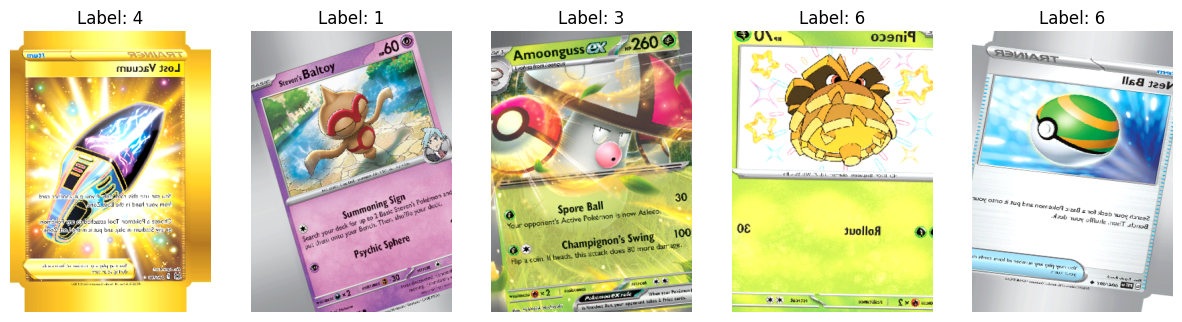

In [9]:
# Mengambil satu batch data latih
x_batch, y_batch = next(train_generator)

# Menampilkan 5 gambar pertama dari batch tersebut
plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.title(f"Label: {y_batch[i].argmax()}")
    plt.axis("off")
plt.show()


In [10]:
# ==========================================
# 3. INISIALISASI MOBILENETV2 (TRANSFER LEARNING)
# ==========================================
print("Membangun Arsitektur Model...")

# Load MobileNetV2 pretrained ImageNet tanpa layer klasifikasi atas (include_top=False)
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Tahap 1: Feature Extraction (Freeze layer dasar)
# Membekukan seluruh layer bawaan MobileNetV2 pada tahap awal
base_model.trainable = False 

# Menambahkan custom layer untuk fine-tuning klasifikasi 10 set kartu
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) # Mengurangi risiko overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

# Menggabungkan base model dengan custom layer
model = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi Model untuk tahap Feature Extraction
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("Model siap untuk dilatih (Tahap 1: Feature Extraction).")


Membangun Arsitektur Model...


C:\Users\aryay\AppData\Local\Temp\ipykernel_7256\3492975265.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 420, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 210, 150,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 210, 150,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 210, 150,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 210, 150,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 210, 150,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 210, 150,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 210, 150,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 210, 150,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 210, 150,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 210, 150,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 210, 150,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 211, 151,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 105, 75,   │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 105, 75,   │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 105, 75,   │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 105, 75,   │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model siap untuk dilatih (Tahap 1: Feature Extraction).


In [11]:
EPOCHS_PHASE_1 = 10

print("Memulai Tahap 1: Feature Extraction...")
history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE_1,
    validation_data=val_generator
)


Memulai Tahap 1: Feature Extraction...
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.1414 - loss: 2.3693 - val_accuracy: 0.1735 - val_loss: 2.2661
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.2168 - loss: 2.2017 - val_accuracy: 0.1794 - val_loss: 2.2238
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.2729 - loss: 2.0854 - val_accuracy: 0.2088 - val_loss: 2.2024
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.2991 - loss: 2.0230 - val_accuracy: 0.2559 - val_loss: 2.1359
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.3190 - loss: 1.9434 - val_accuracy: 0.2853 - val_loss: 2.1030
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.3433 - loss: 1.9118 - val_accuracy: 0.2471 - val_loss: 2.1395
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.3589 - loss: 1.8580 - val_accuracy: 0.2471 - val_loss: 2.1322
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.3819 - 

In [12]:
print("Memulai Tahap 2: Fine-Tuning...")

# Membuka kunci base_model
base_model.trainable = True

# Menentukan batas layer yang akan di-fine-tune (misal: freeze 100 layer pertama)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Kompilasi ulang model dengan learning rate yang JAUH lebih kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Learning rate diturunkan
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Melanjutkan pelatihan
EPOCHS_PHASE_2 = 10
TOTAL_EPOCHS = EPOCHS_PHASE_1 + EPOCHS_PHASE_2

history_phase2 = model.fit(
    train_generator,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_phase1.epoch[-1], # Melanjutkan dari epoch terakhir tahap 1
    validation_data=val_generator
)


Memulai Tahap 2: Fine-Tuning...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 420, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 210, 150,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 210, 150,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 210, 150,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 210, 150,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 210, 150,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 210, 150,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 210, 150,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 210, 150,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 210, 150,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 210, 150,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 210, 150,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 211, 151,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 105, 75,   │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 105, 75,   │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 105, 75,   │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 105, 75,   │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 1,874,250 (7.15 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 10/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.1850 - loss: 2.5309 - val_accuracy: 0.2471 - val_loss: 2.1739
Epoch 11/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.2430 - loss: 2.1873 - val_accuracy: 0.2147 - val_loss: 2.2921
Epoch 12/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.3121 - loss: 1.9842 - val_accuracy: 0.2029 - val_loss: 2.4403
Epoch 13/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.3576 - loss: 1.8232 - val_accuracy: 0.2088 - val_loss: 2.4936
Epoch 14/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.3857 - loss: 1.7544 - val_accuracy: 0.2235 - val_loss: 2.4523
Epoch 15/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.4100 - loss: 1.6845 - val_accuracy: 0.2294 - val_loss: 2.3595
Epoch 16/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.4355 - loss: 1.6274 - val_accuracy: 0.2324 - val_loss: 2.3078
Epoch 17/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.4393 - loss: 1.5950 - val_accuracy: 0.

In [13]:
# Menyimpan model yang sudah dilatih ke folder models/
model_path = os.path.join('models', 'mobilenetv2_pokemon_tcg.keras')
model.save(model_path)
print(f"Model berhasil disimpan di: {model_path}")


Model berhasil disimpan di: models\mobilenetv2_pokemon_tcg.keras


In [14]:
# ==========================================
# 4. EVALUASI MODEL PADA DATA UJI (TEST SET)
# ==========================================
TEST_DIR = os.path.join('data', 'processed', 'test')

# Hanya normalisasi, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # PENTING: Jangan diacak agar y_true dan y_pred sejajar
)

# Menghitung Akurasi dan Loss dasar
print("Mengevaluasi model...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi pada Test Set: {test_acc * 100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")

Found 355 images belonging to 10 classes.
Mengevaluasi model...
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.2535 - loss: 2.1163

Akurasi pada Test Set: 25.35%
Loss pada Test Set: 2.1163


Melakukan prediksi pada Test Set...
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step

=== Laporan Klasifikasi (Classification Report) ===
                       precision    recall  f1-score   support

                  151       1.00      0.03      0.06        32
      destined-rivals       0.21      0.39      0.27        38
       evolving-skies       0.48      0.33      0.39        36
     journey-together       0.50      0.03      0.06        29
          lost-origin       0.67      0.05      0.10        38
       paldea-evolved       0.19      0.72      0.30        43
        paldean-fates       0.81      0.45      0.58        38
 prismatic-evolutions       0.33      0.14      0.20        28
scarlet-violet-promos       0.20      0.09      0.12        34
       surging-sparks       0.11      0.10      0.11        39

             accuracy                           0.25       355
            macro avg       0.45      0.23      0.22       355
         weighted avg       0.44      0.25      0.2

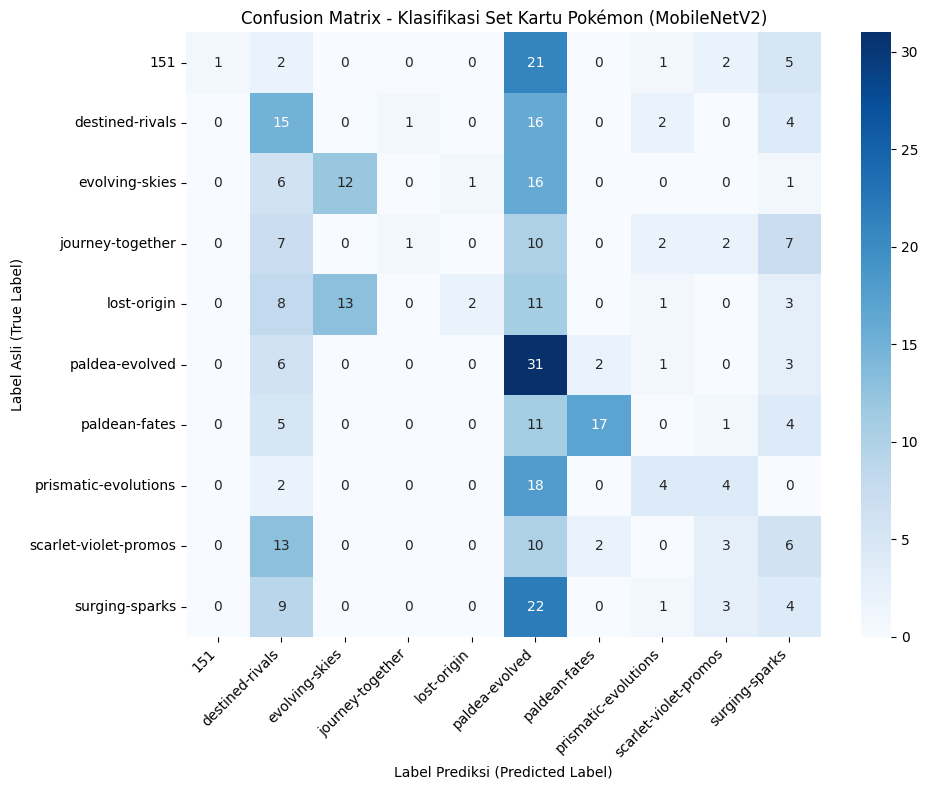

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Melakukan prediksi pada Test Set...")
# Mendapatkan probabilitas prediksi
predictions = model.predict(test_generator)

# Mengambil indeks kelas dengan probabilitas tertinggi (argmax)
y_pred = np.argmax(predictions, axis=1)

# Mengambil label asli dari generator
y_true = test_generator.classes

# Mengambil nama-nama kelas (10 Set Pokémon)
class_names = list(test_generator.class_indices.keys())

# 1. Classification Report (Precision, Recall, F1-Score)
print("\n=== Laporan Klasifikasi (Classification Report) ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Set Kartu Pokémon (MobileNetV2)')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Label Prediksi (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Menyimpan gambar Confusion Matrix ke folder reports (opsional tapi disarankan untuk skripsi)
cm_path = os.path.join('reports', 'confusion_matrix_mobilenet.png')
# Pastikan folder reports ada
os.makedirs('reports', exist_ok=True)
plt.savefig(cm_path)
print(f"Confusion Matrix berhasil disimpan di: {cm_path}")

plt.show()

Menghasilkan Learning Curves...
Learning Curves berhasil disimpan di: reports\learning_curves_mobilenet.png


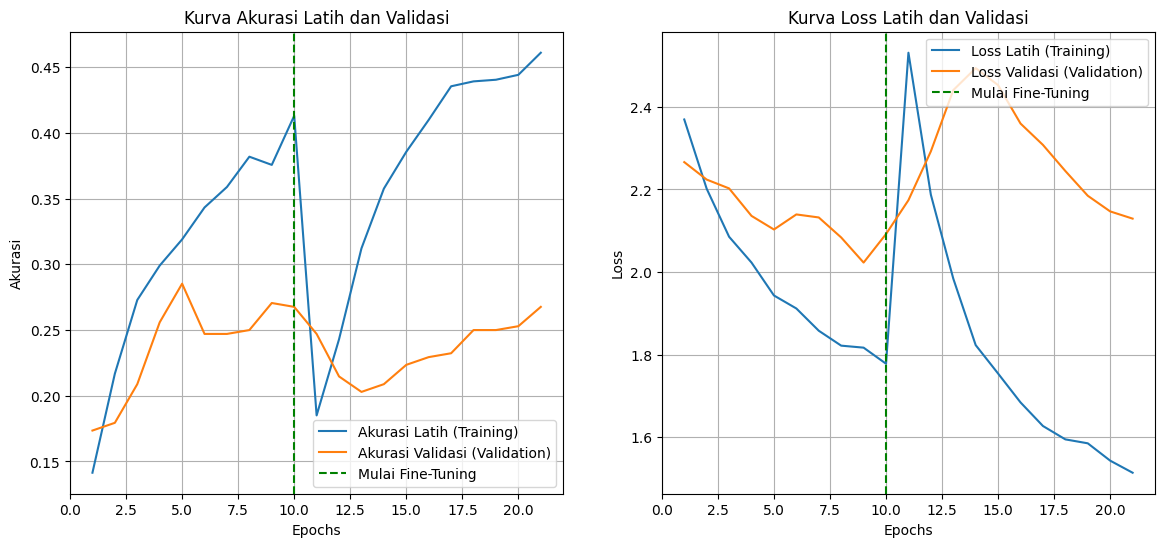

In [16]:
# ==========================================
# 5. VISUALISASI LEARNING CURVES
# ==========================================
print("Menghasilkan Learning Curves...")

# Menggabungkan data metrik dari Tahap 1 (Feature Extraction) dan Tahap 2 (Fine-Tuning)
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Menentukan titik transisi fine-tuning
initial_epochs = len(history_phase1.history['accuracy'])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# 1. Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih (Training)')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Akurasi Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih (Training)')
plt.plot(epochs_range, val_loss, label='Loss Validasi (Validation)')
plt.axvline(x=initial_epochs, color='green', linestyle='--', label='Mulai Fine-Tuning')
plt.title('Kurva Loss Latih dan Validasi')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Menyimpan grafik ke folder reports
lc_path = os.path.join('reports', 'learning_curves_mobilenet.png')
plt.savefig(lc_path)
print(f"Learning Curves berhasil disimpan di: {lc_path}")

plt.show()